# Analisi della diffusione del COVID-19

## Obiettivo del progetto
L'obiettivo di questa esercitazione è analizzare i dati relativi alla diffusione del COVID-19 utilizzando il seguente dataset: 
 https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv

L'analisi verrà sviluppata attraverso le seguenti fasi:
1. Verificare le dimensioni del dataset e i relativi metadati;
2. Per ogni continente individuare il numero di casi fin dall’inizio della pandemia e la percentuale rispetto al totale mondiale del numero di casi;
3. Selezionare i dati relativi all’Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati l’evoluzione del casi totali dall’inizio alla fine dell’anno e il numero di nuovi casi rispetto alla data;
4. Riguardo le nazioni di Italia, Germania e Francia mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da Maggio 2022 (incluso) ad Aprile 2023 (incluso); scrivere un breve commento (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico risultante;
5. Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021 mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospedalizzati per ognuna (colonna hosp_patients); se ci sono dati nulli, commentare se può essere possibile gestirli tramite sostituzione o meno.

## 1. Verificare le dimensioni del dataset e i relativi metadati.

In [1]:
#importo la libreria pandas per lavorare con i dati 
import pandas as pd    

#carico il dataset 
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"

df_covid = pd.read_csv(url)

df_covid.head()  

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [2]:
#EDA
df_covid.info()

#dimensioni del dataset
print("Numero righe:", df_covid.shape[0])
print("Numero colonnne:", df_covid.shape[1])

#nomi colonne
df_covid.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

*Il dataset contiene 429435 righe e 67 colonne. Le colonne comprendono informazioni sui casi di COVID-19. 
Alcune variabili presentano numerosi valori mancanti.*

In [3]:
#la colonna date è di tipo object quindi la converto nel data type datetime
df_covid["date"]

df_covid["date"] = pd.to_datetime(df_covid["date"])

#controllo 
df_covid["date"].dtype 

#verifico quale lasso temporale copre il dataset
print("Data iniziale:", df_covid["date"].min())
print("Data finale:", df_covid["date"].max())

Data iniziale: 2020-01-01 00:00:00
Data finale: 2024-08-14 00:00:00


In [4]:
#statistiche descrittive 
df_covid.describe()

,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,429435,4.118040e+05,4.101590e+05,4.089290e+05,4.118040e+05,410608.000000,409378.000000,411804.000000,410159.000000,408929.000000,...,243817.000000,161741.000000,290689.000000,390299.000000,319127.000000,4.294350e+05,1.341100e+04,13411.000000,13411.000000,13411.000000
mean,2022-04-21 01:06:25.463691008,7.365292e+06,8.017360e+03,8.041026e+03,8.125957e+04,71.852139,72.060828,112096.199420,122.357073,122.713852,...,33.097758,50.649390,3.106895,73.702098,0.722178,1.520336e+08,5.604765e+04,9.766431,10.925353,1772.666404
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.190000,0.100000,53.280000,0.390000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2936.450000
25%,2021-03-05 00:00:00,6.280750e+03,0.000000e+00,0.000000e+00,4.300000e+01,0.000000,0.000000,1916.100000,0.000000,0.000000,...,22.600000,20.860000,1.300000,69.500000,0.600000,5.237980e+05,1.765000e+02,2.060000,-1.500000,116.875000
50%,2022-04-20 00:00:00,6.365300e+04,0.000000e+00,1.200000e+01,7.990000e+02,0.000000,0.000000,29145.480000,0.000000,2.790000,...,33.100000,49.540000,2.500000,75.050000,0.740000,6.336393e+06,6.815200e+03,8.130000,5.660000,1270.800000
75%,2023-06-08 00:00:00,7.582720e+05,0.000000e+00,3.132900e+02,9.574000e+03,0.000000,3.140000,156770.190000,0.000000,56.250000,...,41.500000,82.500000,4.210000,79.460000,0.830000,3.296952e+07,3.912804e+04,15.160000,15.575000,2883.025000
max,2024-08-14 00:00:00,7.758668e+08,4.423623e+07,6.319461e+06,7.057132e+06,103719.000000,14817.000000,763598.600000,241758.230000,34536.890000,...,78.100000,100.000000,13.800000,86.750000,0.960000,7.975105e+09,1.349776e+06,78.080000,378.220000,10293.520000
std,NaN,4.477582e+07,2.296649e+05,8.661611e+04,4.411901e+05,1368.322990,513.636565,162240.412405,1508.778585,559.701663,...,13.853952,31.905236,2.549168,7.387914,0.149237,6.975408e+08,1.568691e+05,12.040658,24.560706,1991.892770


In [5]:
#conteggio valori nulli per colonna 
numero_nulli = df_covid.isna().sum()  
numero_nulli

numero_nulli.sort_values(ascending=False)

weekly_icu_admissions_per_million          418442
weekly_icu_admissions                      418442
excess_mortality_cumulative_per_million    416024
excess_mortality                           416024
excess_mortality_cumulative                416024
                                            ...  
total_deaths                                17631
population                                      0
date                                            0
location                                        0
iso_code                                        0
Length: 67, dtype: int64

In [6]:
#percentuale valori nulli per colonna 
percentuale_nulli = df_covid.isna().mean() * 100  

percentuale_nulli.sort_values(ascending=False).head(20)

weekly_icu_admissions_per_million          97.440125
weekly_icu_admissions                      97.440125
excess_mortality_cumulative_per_million    96.877059
excess_mortality                           96.877059
excess_mortality_cumulative                96.877059
excess_mortality_cumulative_absolute       96.877059
weekly_hosp_admissions_per_million         94.295528
weekly_hosp_admissions                     94.295528
icu_patients                               90.891287
icu_patients_per_million                   90.891287
hosp_patients_per_million                  90.532677
hosp_patients                              90.532677
total_boosters_per_hundred                 87.518484
total_boosters                             87.518484
new_vaccinations                           83.473401
new_tests                                  82.441347
new_tests_per_thousand                     82.441347
people_fully_vaccinated                    81.822395
people_fully_vaccinated_per_hundred        81.

*La presenza dei valori nulli non indica necessariamente l’assenza del fenomeno, può indicare anche che il dato non è disponibile.*

In [7]:
#numero location
print("Numero location presenti nel data set:", df_covid["location"].nunique())

Numero location presenti nel data set: 255


In [8]:
#continenti 
#ci sono dei valori nulli, quindi li tolgo per vedere solo i nomi dei continenti presenti
print("Continenti:", df_covid["continent"].dropna().unique())

Continenti: ['Asia' 'Europe' 'Africa' 'Oceania' 'North America' 'South America']


In [9]:
df_covid[df_covid["continent"].isna()][["location", "iso_code"]].drop_duplicates().head()

,location,iso_code
1674,Africa,OWID_AFR
20092,Asia,OWID_ASI
118569,Europe,OWID_EUR
120253,European Union (27),OWID_EUN
163847,High-income countries,OWID_HIC


*Le righe con valore mancante nella colonna "continent" non rappresentano necessariamente dati incompleti. La colonna "location" non contiene esclusivamente Stati, ma anche dati aggregati (esempio: Europe non è un paese, comprende più paesi. OWID_EUR rappresenta quindi un dato aggregato). Le righe in cui continent è nullo comprendono quindi dati aggregati.*

*Prima dell'analisi sono stati consultati anche i metadati del dataset (in particolare: https://github.com/owid/covid-19-data/blob/master/public/data/README.md?utm_source=chatgpt.com) per comprendere meglio cosa indica ciascuna variabile.*

# 2. Trovare, per ogni continente: a. il numero di casi fin dall’inizio della pandemia; b. la percentuale rispetto al totale mondiale del numero di casi.

In [10]:
#creo una lista con i 6 continenti presenti nel dataset
continenti = ['Asia', 'Europe', 'Africa', 'Oceania', 'North America', 'South America']

In [11]:
#seleziono solo i continenti
df_continenti = df_covid[df_covid["location"].isin(continenti)]

df_continenti.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
1674,OWID_AFR,NaN,Africa,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1675,OWID_AFR,NaN,Africa,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1676,OWID_AFR,NaN,Africa,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1677,OWID_AFR,NaN,Africa,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1678,OWID_AFR,NaN,Africa,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN


In [12]:
#controllo se ci sono valori nulli nella colonna "total_cases"
print("Numero valori nulli nella colonna total_cases:", df_continenti["total_cases"].isna().sum())

Numero valori nulli nella colonna total_cases: 27


In [13]:
#escludo le righe in cui total_cases è nullo 
df_continenti = df_continenti[df_continenti["total_cases"].notna()]

df_continenti.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
1674,OWID_AFR,NaN,Africa,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1675,OWID_AFR,NaN,Africa,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1676,OWID_AFR,NaN,Africa,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1677,OWID_AFR,NaN,Africa,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1678,OWID_AFR,NaN,Africa,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN


In [14]:
#ordino i dati per data così posso selezionare l'ultima riga per ogni continente 
df_continenti = df_continenti.sort_values("date")

df_continenti.head()
df_continenti.tail()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
278858,OWID_NAM,NaN,North America,2024-08-04,124492666.0,454.0,64.86,1671178.0,619.0,88.43,...,NaN,NaN,NaN,NaN,NaN,600323657,NaN,NaN,NaN,NaN
21765,OWID_ASI,NaN,Asia,2024-08-04,301499099.0,4515.0,645.00,1637249.0,17.0,2.43,...,NaN,NaN,NaN,NaN,NaN,4721383370,NaN,NaN,NaN,NaN
3347,OWID_AFR,NaN,Africa,2024-08-04,13145380.0,36.0,5.14,259117.0,0.0,0.00,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
289291,OWID_OCE,NaN,Oceania,2024-08-04,15003352.0,1809.0,258.43,32918.0,16.0,2.29,...,NaN,NaN,NaN,NaN,NaN,45038860,NaN,NaN,NaN,NaN
359237,OWID_SAM,NaN,South America,2024-08-04,68809418.0,1308.0,186.86,1354187.0,1.0,0.14,...,NaN,NaN,NaN,NaN,NaN,436816679,NaN,NaN,NaN,NaN


In [15]:
#per ogni continente prendo l'ultima riga
ultimo_dato_per_continente = (df_continenti.groupby("location").tail(1))

ultimo_dato_per_continente[["location", "date", "total_cases"]]

,location,date,total_cases
120242,Europe,2024-08-04,252916868.0
278858,North America,2024-08-04,124492666.0
21765,Asia,2024-08-04,301499099.0
3347,Africa,2024-08-04,13145380.0
289291,Oceania,2024-08-04,15003352.0
359237,South America,2024-08-04,68809418.0


*Questa tabella mostra, per ciascun continente, l’ultimo valore valido della colonna total_cases. Siccome total_cases è una variabile cumulativa, questo valore rappresenta il numero complessivo di casi registrati dal 5 Gennaio 2020 al 4 Agosto 2024 (lasso di tempo a cui fanno riferimento questi dati).*

In [16]:
#per calcolare la percentuale rispetto al totale mondiale del numero di casi considero le righe relative a "World"
df_mondo = df_covid[df_covid["location"] == "World"]

In [17]:
#anche qui escludo le righe in cui total_cases è nullo e ordino per data 
df_mondo = df_mondo[df_mondo["total_cases"].notna()]

df_mondo.head()

df_mondo = df_mondo.sort_values("date")

df_mondo.head()
df_mondo.tail()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
424398,OWID_WRL,NaN,World,2024-07-31,775819614.0,0.0,8002.29,7056317.0,0.0,129.14,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
424399,OWID_WRL,NaN,World,2024-08-01,775819614.0,0.0,8002.29,7056317.0,0.0,129.14,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
424400,OWID_WRL,NaN,World,2024-08-02,775819614.0,0.0,8002.29,7056317.0,0.0,129.14,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
424401,OWID_WRL,NaN,World,2024-08-03,775819614.0,0.0,8002.29,7056317.0,0.0,129.14,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
424402,OWID_WRL,NaN,World,2024-08-04,775866783.0,47169.0,6738.43,7057132.0,815.0,116.43,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN


In [18]:
#prendo l'ultima riga 
totale_mondiale = df_mondo["total_cases"].iloc[-1]

totale_mondiale

np.float64(775866783.0)

*775866783 rappresenta l’ultimo valore valido di total_cases relativo alla voce World (arco temporale: 2020 - 2024).*

In [19]:
#creo un nuovo df con le colonne che mi occorrono e calcolo la percentuale dei casi di ogni continente sul totale mondiale
casi_per_continente = pd.DataFrame({"location": ultimo_dato_per_continente["location"],"total_cases": ultimo_dato_per_continente["total_cases"]})
casi_per_continente

casi_per_continente["percentuale"] = (casi_per_continente["total_cases"] / totale_mondiale * 100)
casi_per_continente

casi_per_continente["percentuale"] = (casi_per_continente["percentuale"].round(2))
casi_per_continente

,location,total_cases,percentuale
120242,Europe,252916868.0,32.60
278858,North America,124492666.0,16.05
21765,Asia,301499099.0,38.86
3347,Africa,13145380.0,1.69
289291,Oceania,15003352.0,1.93
359237,South America,68809418.0,8.87


In [20]:
#ordino il risultato finale, dal continente con più casi a quello con meno casi
casi_per_continente = casi_per_continente.sort_values(by="total_cases", ascending=False)
casi_per_continente

,location,total_cases,percentuale
21765,Asia,301499099.0,38.86
120242,Europe,252916868.0,32.60
278858,North America,124492666.0,16.05
359237,South America,68809418.0,8.87
289291,Oceania,15003352.0,1.93
3347,Africa,13145380.0,1.69


*Per ogni continente (colonna location) è stato selezionato l’ultimo valore valido della colonna total_cases perchè è una variabile cumulativa. L’Asia presenta il numero maggiore di casi, con 301499099 casi, pari al 38,86% del totale mondiale. Al secondo posto abbiamo l’Europa con il 32,60% di casi rispetto al totale mondiale. Al terzo posto il Nord America con il 16,05%.*

## 3. Selezionare i dati relativi all’Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno  misurazioni; quindi mostrare con dei grafici adeguati:
## a. l’evoluzione del casi totali dall’inizio alla fine dell’anno
## b. il numero di nuovi casi rispetto alla data

In [21]:
#creiamo un df che contenga solo le righe relative all'Italia
df_italia = df_covid[df_covid["location"] == "Italy"]

df_italia["location"].unique()

df_italia.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
185275,ITA,Europe,Italy,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,27.8,NaN,3.18,83.51,0.89,59037472,-1904.1,-12.37,-12.37,-32.0
185276,ITA,Europe,Italy,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
185277,ITA,Europe,Italy,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
185278,ITA,Europe,Italy,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
185279,ITA,Europe,Italy,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN


In [22]:
#seleziono solo le righe che si riferiscono al 2022
df_italia_2022 = df_italia[df_italia["date"].dt.year == 2022]

print("Prima data:", df_italia_2022["date"].min())

print("Ultima data:", df_italia_2022["date"].max())

Prima data: 2022-01-01 00:00:00
Ultima data: 2022-12-31 00:00:00


In [23]:
#controllo i valori nulli e come sono inseriti i dati
df_italia_2022["new_cases"].isna().sum()

np.int64(0)

In [24]:
df_italia_2022[["date", "new_cases"]].head(20)

,date,new_cases
186002,2022-01-01,0.0
186003,2022-01-02,644604.0
186004,2022-01-03,0.0
186005,2022-01-04,0.0
186006,2022-01-05,0.0
186007,2022-01-06,0.0
186008,2022-01-07,0.0
186009,2022-01-08,0.0
186010,2022-01-09,1014262.0
186011,2022-01-10,0.0


In [25]:
df_italia_2022[["date", "new_cases"]].tail(20)

,date,new_cases
186347,2022-12-12,0.0
186348,2022-12-13,0.0
186349,2022-12-14,0.0
186350,2022-12-15,0.0
186351,2022-12-16,0.0
186352,2022-12-17,0.0
186353,2022-12-18,174187.0
186354,2022-12-19,0.0
186355,2022-12-20,0.0
186356,2022-12-21,0.0


*Da questi dati emerge che l'aggiornamento delle numeriche avviene con cadenza settimanale e non giornaliera, quindi il valore 0.0 nella maggior parte dei giorni non indica mancanza di nuovi casi ma che semplicemente non sono stati aggiornati i dati in corrispondenza di quel giorno.*
*Lo zero quindi non rappresenta una misurazione in questo caso.*

In [26]:
#seleziono quindi solo i giorni in cui è stata registrata la rilevazione dei nuovi casi 
df_italia_2022_misurazioni = df_italia_2022[df_italia_2022["new_cases"] != 0]
df_italia_2022_misurazioni.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
186003,ITA,Europe,Italy,2022-01-02,6267035.0,644604.0,92086.29,137513.0,983.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,168226.30,12.99,8.06,2849.48
186010,ITA,Europe,Italy,2022-01-09,7281297.0,1014262.0,144894.57,138881.0,1368.0,195.43,...,27.8,NaN,3.18,83.51,0.89,59037472,168831.80,12.89,3.94,2859.74
186017,ITA,Europe,Italy,2022-01-16,8549450.0,1268153.0,181164.71,140856.0,1975.0,282.14,...,27.8,NaN,3.18,83.51,0.89,59037472,170089.10,12.83,8.03,2881.04
186024,ITA,Europe,Italy,2022-01-23,9781191.0,1231741.0,175963.00,143296.0,2440.0,348.57,...,27.8,NaN,3.18,83.51,0.89,59037472,171694.19,12.80,10.40,2908.22
186031,ITA,Europe,Italy,2022-01-30,10821375.0,1040184.0,148597.71,145914.0,2618.0,374.00,...,27.8,NaN,3.18,83.51,0.89,59037472,174151.69,12.84,16.50,2949.85


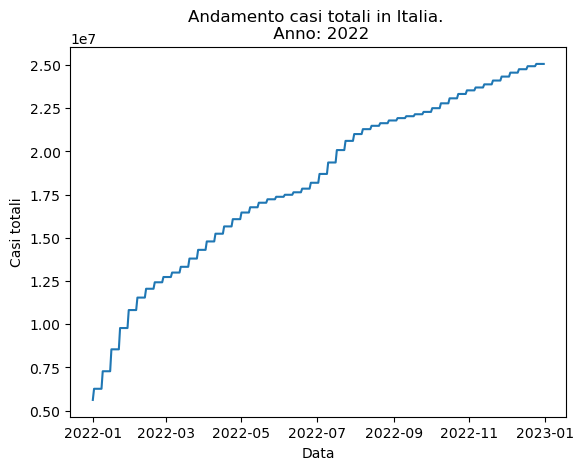

In [27]:
#importo la libreria per lavorare con i grafici 
import matplotlib.pyplot as plt

#creo il grafico a linee dei casi totali
plt.plot(df_italia_2022["date"], df_italia_2022["total_cases"])

plt.title("Andamento casi totali in Italia. \n Anno: 2022")
plt.xlabel("Data")
plt.ylabel("Casi totali")

plt.show()

*Il grafico mostra l’andamento cumulativo dei casi totali di COVID-19 in Italia nel 2022. Dal momento che total_cases è una variabile cumulativa, contiene il totale progressivo dei casi registrati fino a ciascuna data, la curva quindi può aumentare oppure rimanere stabile.*

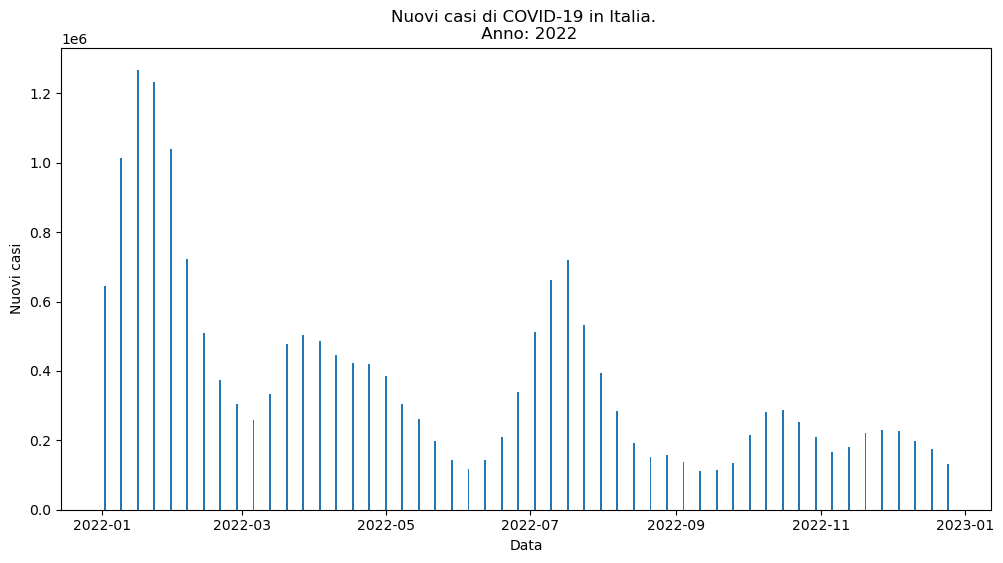

In [28]:
#imposto la dimensione del nuovo grafico
plt.figure(figsize=(12,6))

#creo un grafico a barre relativo ai nuovi casi
plt.bar(df_italia_2022_misurazioni["date"], df_italia_2022_misurazioni["new_cases"])

plt.title("Nuovi casi di COVID-19 in Italia. \n Anno: 2022")
plt.xlabel("Data")
plt.ylabel("Nuovi casi")

plt.show()

*Il grafico mostra il numero di nuovi casi registrati nelle rilevazioni del 2022. A differenza della variabile total_cases, che è cumulativa e quindi può rappresentare una curva che o rimane uguale o aumenta, new_cases rappresenta i casi registrati in ogni rilevazione. Per questo motivo il grafico evidenzia periodi con un numero maggiore di nuovi casi e altri con un numero minore.*

## 4. Riguardo le nazioni di Italia, Germania e Francia:
## a. mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso)
## b. scrivere un breve commento (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico risultante

In [29]:
#creo una lista con Italia, Germania e Francia e il df con i dati filtrati 
nazioni = ["Italy", "Germany", "France"]

df_icu = df_covid[df_covid["location"].isin(nazioni)]

df_icu["location"].unique()

array(['France', 'Germany', 'Italy'], dtype=object)

In [30]:
#nel df seleziono il periodo Maggio 2022 - Aprile 2023
df_icu = df_icu[(df_icu["date"] >= "2022-05-01") & (df_icu["date"] <= "2023-04-30")]

#controllo 
print("Prima data:", df_icu["date"].min())

print("Ultima data:", df_icu["date"].max())

Prima data: 2022-05-01 00:00:00
Ultima data: 2023-04-30 00:00:00


In [31]:
#controllo dei valori nulli 
print("Numero di valori nulli nella colonna icu_patients:", df_icu["icu_patients"].isna().sum())

Numero di valori nulli nella colonna icu_patients: 30


In [32]:
#tengo solo le righe in cui icu_patients non è nullo
df_icu = df_icu[df_icu["icu_patients"].notna()]

#controllo
df_icu["icu_patients"].isna().sum()

np.int64(0)

In [33]:
#creo le tre serie separate per ciascuna nazione 
icu_italia = df_icu[df_icu["location"] == "Italy"]["icu_patients"]

icu_germania = df_icu[df_icu["location"] == "Germany"]["icu_patients"]

icu_francia = df_icu[df_icu["location"] == "France"]["icu_patients"]

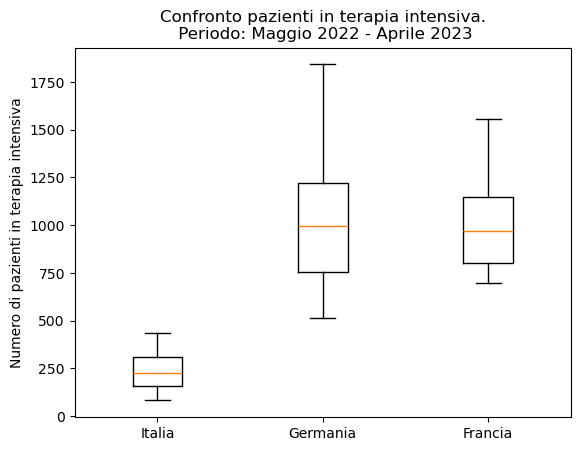

In [34]:
#creo il boxplot
plt.boxplot([icu_italia, icu_germania, icu_francia], tick_labels=["Italia", "Germania", "Francia"])

plt.title("Confronto pazienti in terapia intensiva.\n Periodo: Maggio 2022 - Aprile 2023")
plt.ylabel("Numero di pazienti in terapia intensiva")

plt.show()

*Il boxplot mostra la distribuzione dei pazienti in terapia intensiva nei tre Paesi nel periodo tra Maggio 2022 e Aprile 2023. L'Italia ha registrato un numero di pazienti in terapia intensiva inferiore rispetto a Germania e Francia. Le distribuzioni di Germania e Francia presentano una maggiore variabilità nel numero di pazienti ricoverati e risultano abbastanza simili, con una mediana intorno ai 1000 pazienti. La Germania presenta una dispersione di valori complessivamente più ampia rispetto alla Francia.*

## 5. Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:
## a. mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients);
## b. se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno.

*La colonna hosp_patients indica il numero di pazienti ricoverati in ospedale in un dato giorno (https://github.com/owid/covid-19-data/blob/master/public/data/README.md?utm_source=chatgpt.com#hospital--icu). La traccia dell'esercizio chiede di fare la somma di questa colonna ma sommare il numero di pazienti ricoverati giorno per giorno in realtà non rappresenta il numero di persone ricoverate (perché ad esempio la stessa persona può essere ricoverata per più giorni).*

In [35]:
#creo una lista con Italia, Germania, Francia e Spagna e il df con i dati filtrati 
nazioni_2 = ["Italy", "Germany", "France", "Spain"]

df_hosp_pz = df_covid[df_covid["location"].isin(nazioni_2)]

In [36]:
#nel df seleziono estraggo solo l'anno 2021
df_hosp_pz = df_hosp_pz[df_hosp_pz["date"].dt.year == 2021]

#controllo 
print("Prima data:", df_hosp_pz["date"].min())

print("Ultima data:", df_hosp_pz["date"].max())

Prima data: 2021-01-01 00:00:00
Ultima data: 2021-12-31 00:00:00


In [37]:
#controllo dei valori nulli 
print("Numero di valori nulli nella colonna hosp_patients:", df_hosp_pz["hosp_patients"].isna().sum())

Numero di valori nulli nella colonna hosp_patients: 365


*I dati nulli sono circa un quarto del dataset e non possiamo sostituirli perchè la colonna hosp_patients indica il numero di pazienti ricoverati in ospedale in una determinata data, quindi se sostituisco con 0 sto affermando che in quel giorno non c'era nessun ricoverato ma questa affermazione è sbagliata perchè io non posso saperlo. Anche la sostituzione con la media o con la mediana in questo caso è sbagliata perchè anche qui inserirei un dato inventato. La soluzione più corretta in questo caso è ignorare i valori nulli e Pandas lo fa automaticamente.*

In [38]:
#raggruppo per nazione e calcolo la somma dei pazienti ospitalizzati
somma_hosp_pz = df_hosp_pz.groupby("location")["hosp_patients"].sum()

somma_hosp_pz

location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64

In [39]:
#per capire come mai la somma per la Germania è pari a 0 controllo i valori non nulli per ciascuna nazione 
df_hosp_pz.groupby("location")["hosp_patients"].count()

location
France     365
Germany      0
Italy      365
Spain      365
Name: hosp_patients, dtype: int64

*Nel dataset **non** sono presenti dati sui pazienti ricoverati in ospedale (hosp_patients) per la Germania nel 2021.*

*Pandas restituisce una somma pari a 0, ma questo valore non indica l'assenza di pazienti ospedalizzati: indica semplicemente che il dataset non contiene dati per la Germania in quello slot temporale, di conseguenza non ha senso sostituire i valori nulli con 0 o con altri valori.*

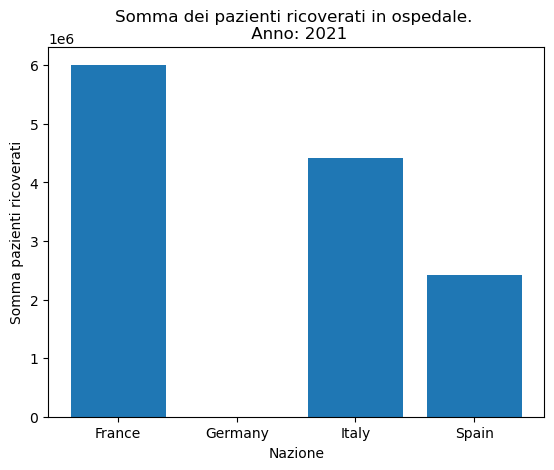

In [40]:
#creo un grafico a barre della somma dei pazienti ospedalizzati
plt.bar(somma_hosp_pz.index,somma_hosp_pz.values)

plt.title("Somma dei pazienti ricoverati in ospedale. \n Anno: 2021")
plt.xlabel("Nazione")
plt.ylabel("Somma pazienti ricoverati")

plt.show()

*Il grafico mostra che la Francia presenta la somma più alta delle ospedalizzazioni giornaliere nel 2021 (6008717), seguita da Italia (4419950) e Spagna (2411706).*
**Nessun commento invece possiamo fare sulla Germania: la barra a zero non significa che non abbia avuto pazienti ospedalizzati ma che nel dataset nel 2021 non sono presenti i valori dei pazienti ricoverati in ospedale.**

*Lo zero nel grafico per la Germania in questo caso non rappresenta una misurazione!*